# Исходные данные

In [28]:
import math
import pandas as pd
import matplotlib.pyplot as plt


Lambda = 48      # заявок в сутки
t = 10         # минут
alpha = 6        # коэффициент затрат
n = 4            # не более n заявок в очереди

# =====================================
# Параметры системы
# =====================================

lam = Lambda / 24          # заявок в час
mu = 60 / t               # обслуживаний в час


# Функции для M/M/k

In [29]:
def p0(k, a):
    rho = a / k

    s = sum((a ** i) / math.factorial(i)
            for i in range(k))

    last = ((a ** k) /
            math.factorial(k)) * (1 / (1 - rho))

    return 1 / (s + last)


def queue_characteristics(k):

    a = lam / mu
    rho = a / k

    P0 = p0(k, a)

    Lq = (P0 * (a ** k) * rho /(math.factorial(k) * ((1 - rho) ** 2)))

    L = Lq + a

    Wq = Lq / lam
    W = L / lam

    return {
        "k": k,
        "rho": rho,
        "P0": P0,
        "Lq": Lq,
        "L": L,
        "Wq": Wq,
        "W": W
    }

# Поиск kmin и kopt

In [30]:
# =====================================
# Поиск kmin
# =====================================

kmin = 1

while True:

    rho = lam / (kmin * mu)

    if rho < 1:
        break

    kmin += 1


# =====================================
# Поиск kopt
# =====================================

costs = []

for k in range(kmin, 16):

    data = queue_characteristics(k)

    cost = k + alpha * data["W"]

    costs.append({
        "k": k,
        "cost": cost,
        **data
    })

df_cost = pd.DataFrame(costs)

best_row = df_cost.loc[df_cost["cost"].idxmin()]

kopt = int(best_row["k"])


# Характеристики

In [31]:
result_kmin = queue_characteristics(kmin)
result_kopt = queue_characteristics(kopt)

print("\nХарактеристики системы:")

# =====================================
# Вероятность того,
# что в очереди не более n заявок
# =====================================

def probability_queue_not_more_than_n(k, n):

    a = lam / mu
    rho = a / k

    P0 = p0(k, a)

    probabilities = []

    for state in range(k + n + 1):

        if state < k:
            p = P0 * (a ** state) / math.factorial(state)
        else:
            p = (P0 * (a ** state) / (math.factorial(k) * (k ** (state - k))))

        probabilities.append(p)

    return sum(probabilities)

prob = probability_queue_not_more_than_n(kopt, n)


print("\n" + "=" * 70)
print("АНАЛИЗ СИСТЕМЫ МАССОВОГО ОБСЛУЖИВАНИЯ (M/M/k)")
print("=" * 70)

print("\nИсходные параметры системы:")
print(f"  Интенсивность поступления λ = {lam:.4f} заявок/час")
print(f"  Интенсивность обслуживания μ = {mu:.4f} заявок/час")
print(f"  Среднее число заявок в сутки = {Lambda}")
print(f"  Среднее время обслуживания = {t} минут")

print("\n" + "-" * 70)
print("1. ОПРЕДЕЛЕНИЕ ЧИСЛА КАНАЛОВ ОБСЛУЖИВАНИЯ")
print("-" * 70)

print(f"Минимальное число каналов (kmin): {kmin}")
print("Условие стационарности выполняется при данном значении,")
print("что гарантирует отсутствие бесконечного роста очереди.")

print(f"\nОптимальное число каналов (kopt): {kopt}")
print("Данное значение выбрано по минимальному значению функции затрат.")

print("\n" + "-" * 70)
print("2. СРАВНЕНИЕ ХАРАКТЕРИСТИК СИСТЕМЫ")
print("-" * 70)

print("\nПоказатели при kmin:")
print(f"  Коэффициент загрузки (ρ): {result_kmin['rho']:.4f}")
print(f"  Вероятность простоя (P0): {result_kmin['P0']:.4f}")
print(f"  Средняя длина очереди (Lq): {result_kmin['Lq']:.4f}")
print(f"  Среднее число заявок в системе (L): {result_kmin['L']:.4f}")
print(f"  Среднее время ожидания (Wq): {result_kmin['Wq']:.4f} ч")
print(f"  Среднее время в системе (W): {result_kmin['W']:.4f} ч")

print("\nПоказатели при kopt:")
print(f"  Коэффициент загрузки (ρ): {result_kopt['rho']:.4f}")
print(f"  Вероятность простоя (P0): {result_kopt['P0']:.4f}")
print(f"  Средняя длина очереди (Lq): {result_kopt['Lq']:.4f}")
print(f"  Среднее число заявок в системе (L): {result_kopt['L']:.4f}")
print(f"  Среднее время ожидания (Wq): {result_kopt['Wq']:.4f} ч")
print(f"  Среднее время в системе (W): {result_kopt['W']:.4f} ч")

print("\n" + "-" * 70)
print("3. АНАЛИЗ ЭФФЕКТИВНОСТИ")
print("-" * 70)

print("Сравнение показывает:")
print(f"  • Средняя длина очереди уменьшилась с {result_kmin['Lq']:.4f} до {result_kopt['Lq']:.4f}")
print(f"  • Время ожидания уменьшилось с {result_kmin['Wq']:.4f} до {result_kopt['Wq']:.4f} часов")
print(f"  • Время пребывания в системе уменьшилось с {result_kmin['W']:.4f} до {result_kopt['W']:.4f} часов")

print("\n" + "-" * 70)
print("4. ВЕРОЯТНОСТНЫЙ АНАЛИЗ")
print("-" * 70)

print(f"Вероятность того, что в очереди не более {n} заявок:")
print(f"  P = {prob:.4f} ({prob*100:.2f}%)")


Характеристики системы:

АНАЛИЗ СИСТЕМЫ МАССОВОГО ОБСЛУЖИВАНИЯ (M/M/k)

Исходные параметры системы:
  Интенсивность поступления λ = 2.0000 заявок/час
  Интенсивность обслуживания μ = 6.0000 заявок/час
  Среднее число заявок в сутки = 48
  Среднее время обслуживания = 10 минут

----------------------------------------------------------------------
1. ОПРЕДЕЛЕНИЕ ЧИСЛА КАНАЛОВ ОБСЛУЖИВАНИЯ
----------------------------------------------------------------------
Минимальное число каналов (kmin): 1
Условие стационарности выполняется при данном значении,
что гарантирует отсутствие бесконечного роста очереди.

Оптимальное число каналов (kopt): 1
Данное значение выбрано по минимальному значению функции затрат.

----------------------------------------------------------------------
2. СРАВНЕНИЕ ХАРАКТЕРИСТИК СИСТЕМЫ
----------------------------------------------------------------------

Показатели при kmin:
  Коэффициент загрузки (ρ): 0.3333
  Вероятность простоя (P0): 0.6667
  Средняя длина оч

# Графики

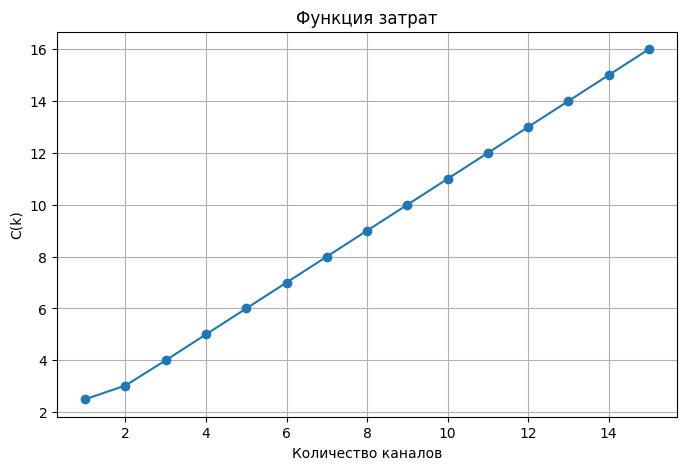

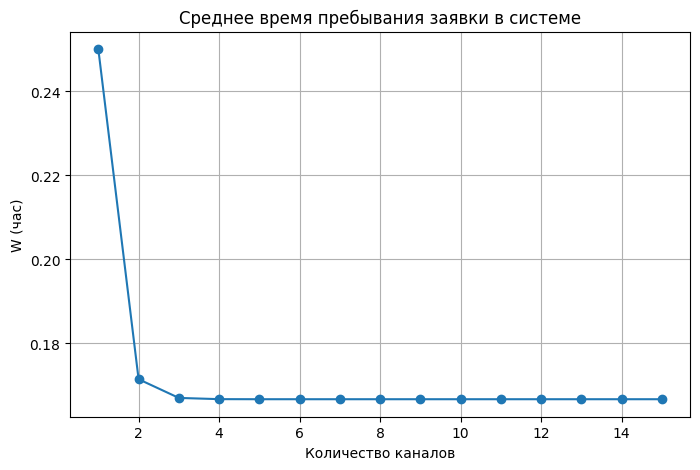

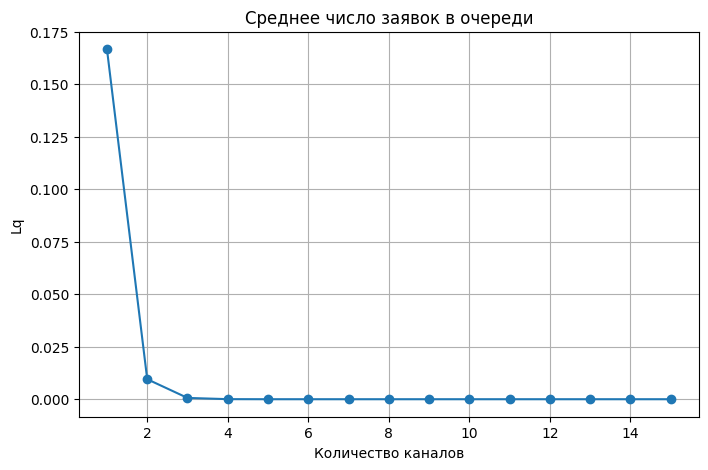

In [32]:
# =====================================
# График функции затрат
# =====================================

plt.figure(figsize=(8, 5))
plt.plot(
    df_cost["k"],
    df_cost["cost"],
    marker="o"
)
plt.title("Функция затрат")
plt.xlabel("Количество каналов")
plt.ylabel("C(k)")
plt.grid(True)
plt.show()

# =====================================
# График среднего времени в системе
# =====================================

plt.figure(figsize=(8, 5))
plt.plot(
    df_cost["k"],
    df_cost["W"],
    marker="o"
)
plt.title("Среднее время пребывания заявки в системе")
plt.xlabel("Количество каналов")
plt.ylabel("W (час)")
plt.grid(True)
plt.show()

# =====================================
# График средней длины очереди
# =====================================

plt.figure(figsize=(8, 5))
plt.plot(
    df_cost["k"],
    df_cost["Lq"],
    marker="o"
)
plt.title("Среднее число заявок в очереди")
plt.xlabel("Количество каналов")
plt.ylabel("Lq")
plt.grid(True)
plt.show()